# 3. Estimación de la constante de enfriamiento k

**Objetivo:** estimar la constante $k$ para la casa de guadua y la casa de plástico usando la ley de enfriamiento de Newton y los datos limpios del experimento.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(Path('datos_limpios.csv'))
df.head()

,muestra,tiempo_min,T_guadua,H_guadua,T_plastico,H_plastico,T_ambiente,H_ambiente
0,1,0,0.6,0.0,0.8,55.0,-2.4,10.0
1,2,1,24.1,55.0,25.5,60.0,20.1,63.0
2,3,2,24.3,55.0,25.9,60.0,20.1,63.0
3,4,3,24.2,55.0,25.1,60.0,20.1,63.0
4,5,4,24.4,55.0,25.2,60.0,20.0,63.0


## Método de estimación

Primero se calculan valores locales de $k$ entre pares de muestras consecutivas y luego se resume su comportamiento con media, desviación estándar y mediana.

In [4]:
def estimar_k_local(temperatura, ambiente, dt=1.0):
    temperatura = np.asarray(temperatura, dtype=float)
    ambiente = np.asarray(ambiente, dtype=float)
    delta_ambiente = temperatura[:-1] - ambiente[:-1]
    delta_temperatura = temperatura[1:] - temperatura[:-1]
    mascara = np.abs(delta_ambiente) > 1e-6
    k_local = -delta_temperatura[mascara] / (dt * delta_ambiente[mascara])  
    k_local = k_local[np.isfinite(k_local)]
    k_local = k_local[(k_local > 0) & (k_local < 0.1)]
    return k_local

k_guadua_local = estimar_k_local(df['T_guadua'], df['T_ambiente'])
k_plastico_local = estimar_k_local(df['T_plastico'], df['T_ambiente'])

resumen_k = pd.DataFrame({
    'Material': ['Guadua', 'Plástico'],
    'k promedio (1/min)': [np.mean(k_guadua_local), np.mean(k_plastico_local)],
    'Desviación estándar': [np.std(k_guadua_local), np.std(k_plastico_local)],
    'Mediana': [np.median(k_guadua_local), np.median(k_plastico_local)],
    'N muestras': [len(k_guadua_local), len(k_plastico_local)]
}).round(6)

resumen_k

,Material,k promedio (1/min),Desviación estándar,Mediana,N muestras
0,Guadua,0.054529,0.024019,0.052632,2636
1,Plástico,0.049334,0.023841,0.047619,2890


## Comparación visual

La barra muestra el promedio estimado de $k$ para cada material. Un valor mayor indica una respuesta más rápida frente a la temperatura ambiente.

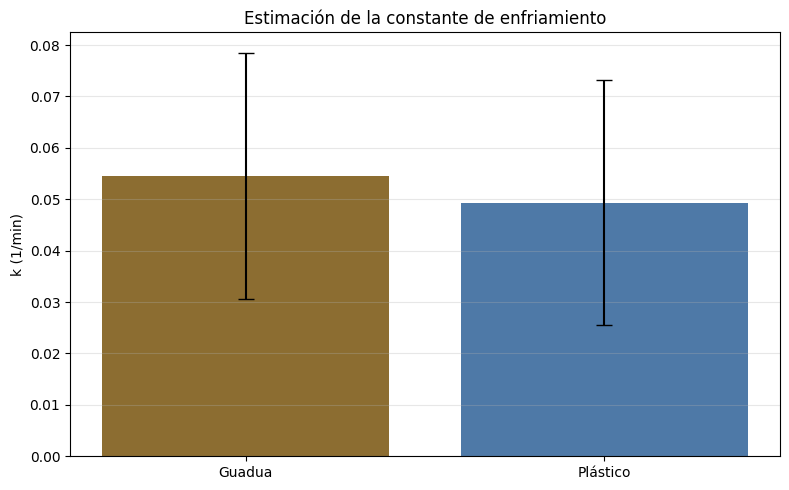

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(resumen_k['Material'], resumen_k['k promedio (1/min)'], yerr=resumen_k['Desviación estándar'], color=['#8c6d31', '#4e79a7'], capsize=6)
plt.ylabel('k (1/min)')
plt.title('Estimación de la constante de enfriamiento')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()